In [34]:
# Importing the required libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split

In [35]:
# Reading the csv file and putting it into 'df' object.
df = pd.read_csv('D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\adv ml-Tree Models-12\\heart_v2.csv')

In [36]:
df.columns

Index(['age', 'sex', 'BP', 'cholestrol', 'heart disease'], dtype='object')

In [37]:
df.head()

,age,sex,BP,cholestrol,heart disease
0,70,1,130,322,1
1,67,0,115,564,0
2,57,1,124,261,1
3,64,1,128,263,0
4,74,0,120,269,0


In [38]:
# Putting feature variable to X
X = df.drop('heart disease',axis=1)

# Putting response variable to y
y = df['heart disease']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)
X_train.shape, X_test.shape

((189, 4), (81, 4))

In [40]:
#Fitting the decision tree with default hyperparameters, apart from max_depth which is 3 so that we can plot and read the tree.

In [41]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

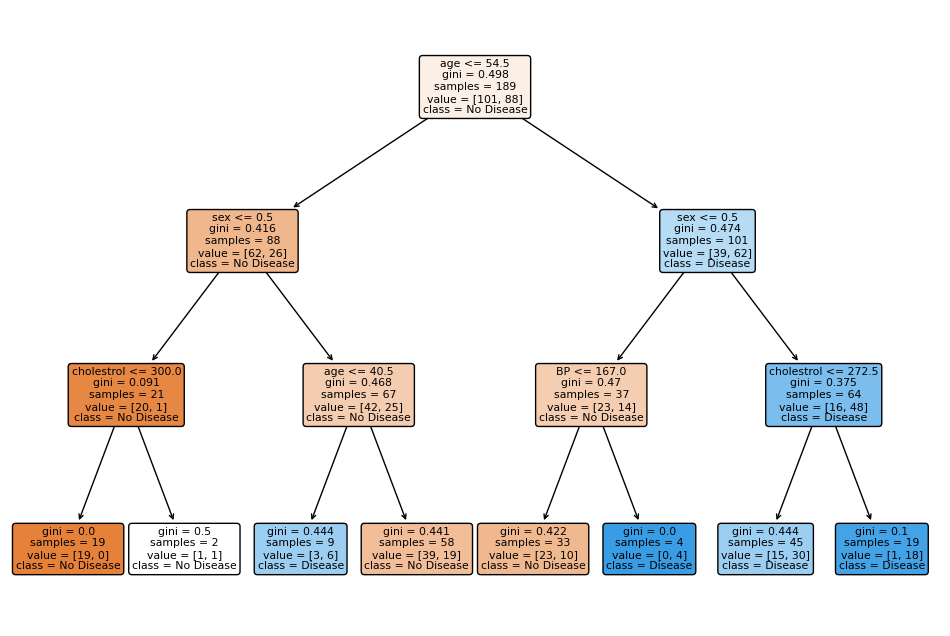

In [43]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=X.columns, class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, max_depth=3)
plt.show()

In [44]:
#Evaluating model performance

In [45]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [46]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [47]:
print(accuracy_score(y_train, y_train_pred))
confusion_matrix(y_train, y_train_pred)

0.7407407407407407


array([[82, 19],
       [30, 58]], dtype=int64)

In [ ]:
#accuracy = 0.74 - model correctly predicted 74% of training samples
#accuracy = correct predictions/Total predictions = (82+58) / (82+19+30+58) = 140/189 = 0.74

#[[82, 19],
# [30, 58]]
                       # Predicted: No disease      Predicted: Disease
#Actual: No Disease         82 (True Negative)        19 (False Positive)
#Actual: Disease            30 (False Negative)       58 (True Positive) 

#TP=58 : correctly identified patients with heart disease
#TN=82: correctly identified healthy patients
#FP = 19 : healthy patients wrongly predicted as diseased
#FN=30 : diseased patients missed by the model

In [48]:
print(accuracy_score(y_test, y_test_pred))
confusion_matrix(y_test, y_test_pred)

0.6049382716049383


array([[35, 14],
       [18, 14]], dtype=int64)